Netflix Movies & TV Shows EDA Project

1. Dataset Introduction

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (2).csv


In [ ]:
import os
print(os.listdir())

['.config', 'netflix_titles (2).csv', 'netflix_titles.csv', 'netflix_titles (1).csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv('netflix_titles.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Dataset Overview

The dataset contains information about Netflix Movies and TV Shows.
It includes details such as title, director, cast, country, release year, rating, and duration.
The dataset is useful for analyzing Netflix content trends and distribution.
Exploratory Data Analysis (EDA) is performed to discover patterns and insights.
Data cleaning is required to handle missing values and improve data quality.

2. Data Cleaning

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


Cleaning Report
Missing values in director, cast, country, date_added, rating, and duration were handled appropriately. No duplicate records were found in the dataset. The dataset is now ready for analysis

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


Insight 1:

Movies dominate Netflix content with 6,131 titles, while TV Shows account for 2,676 titles. This indicates that Netflix focuses more on movies than TV Shows.

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


Insight 2:
 The United States contributes the highest amount of Netflix content with 2,818 titles, followed by India with 972 titles. This shows that Netflix's content library is heavily dominated by content from the United States.

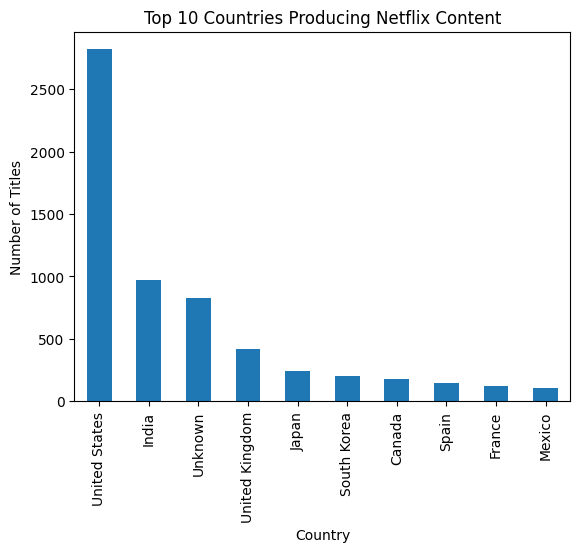

In [ ]:
import matplotlib.pyplot as plt

df['country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()

In [ ]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3211
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


Insight 3:
 TV-MA is the most common content rating on Netflix with 3,211 titles, followed by TV-14 with 2,160 titles. This suggests that Netflix's content library is largely targeted toward mature and teenage audiences.

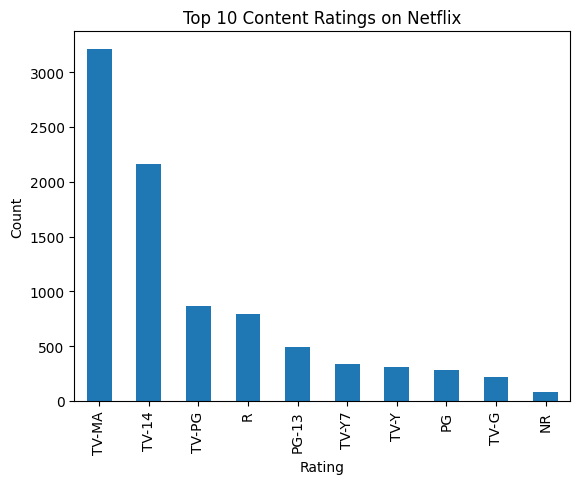

In [ ]:
import matplotlib.pyplot as plt

df['rating'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [ ]:
df['release_year'].value_counts().sort_index().tail(15)

,count
release_year,
2007,88
2008,136
2009,152
2010,194
2011,185
2012,237
2013,288
2014,352
2015,560


Insight 4:
 Netflix experienced rapid content growth between 2015 and 2019. The highest number of titles were released in 2018, indicating a period of significant expansion in Netflix's content library.

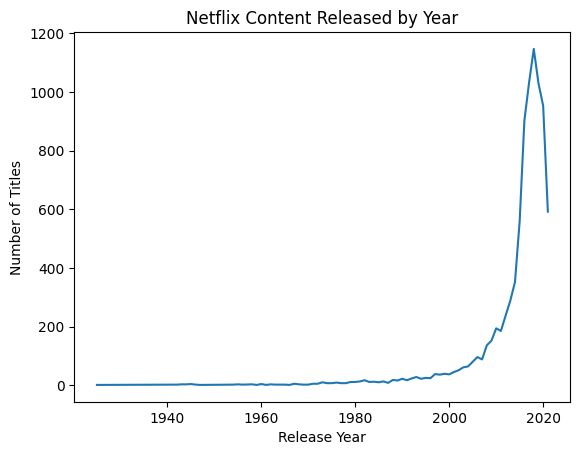

In [ ]:
import matplotlib.pyplot as plt

df['release_year'].value_counts().sort_index().plot(kind='line')

plt.title('Netflix Content Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

In [ ]:
df['director'].value_counts().head(10)

,count
director,
Unknown,2634
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


Insight 5:
 A large number of titles have no director information available. Among the identified directors, Rajiv Chilaka has the highest number of titles on Netflix, indicating a strong presence of his work on the platform.

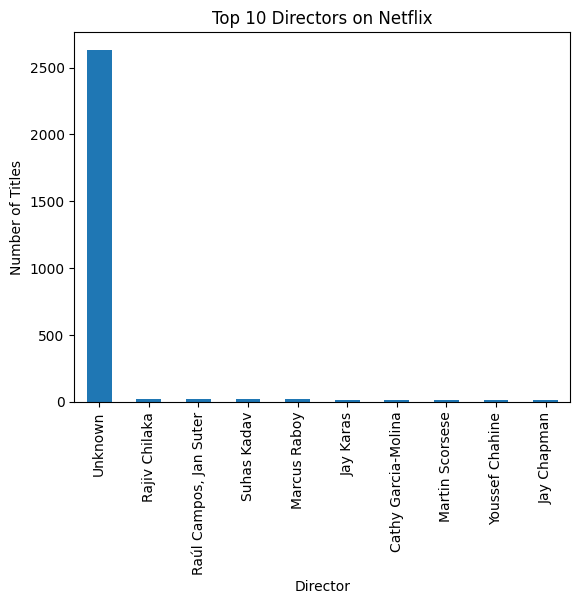

In [ ]:
df['director'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=90)
plt.show()

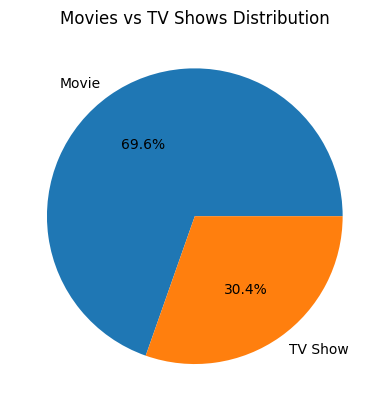

In [ ]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Movies vs TV Shows Distribution')
plt.ylabel('')
plt.show()

In [ ]:
import os
print(os.listdir())

['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv('netflix_titles.csv')

print(df.shape)

(8807, 12)


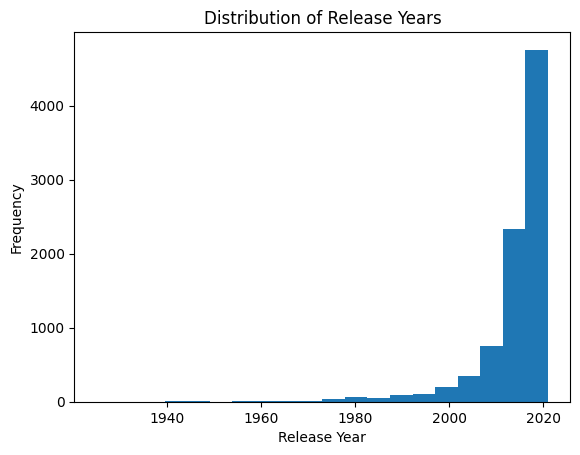

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['release_year'], bins=20)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()

Business Recommendations:

Netflix should continue investing in movie content as movies make up the majority of the catalog.

Netflix can expand production in countries beyond the United States and India.

More family-friendly content could balance the large amount of TV-MA content.

Consistent content additions help maintain platform growth and engagement.

Missing director information should be reduced to improve data quality and analysis.

Short Note:
The most interesting finding from this analysis was the rapid growth of Netflix content after 2015, showing how quickly the platform expanded its library. Another key observation was that movies dominate over TV shows in the dataset. It was also surprising to see that a large amount of content comes from the United States compared to other countries. Overall, Netflix shows a strong focus on global expansion and mature-audience content